In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")

In [2]:
df = pd.read_csv("infection_data.csv")

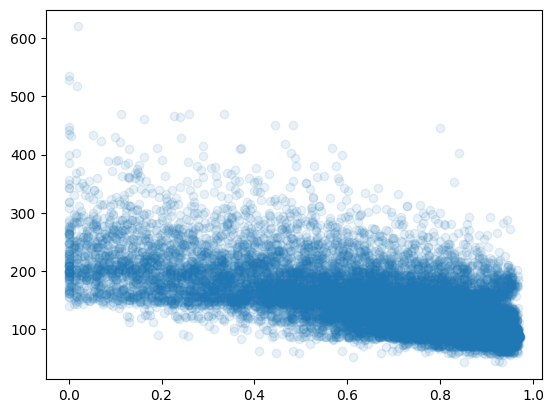

In [62]:
plt.scatter(df["pfemp_variant_frac"], df["duration"], alpha=0.1)

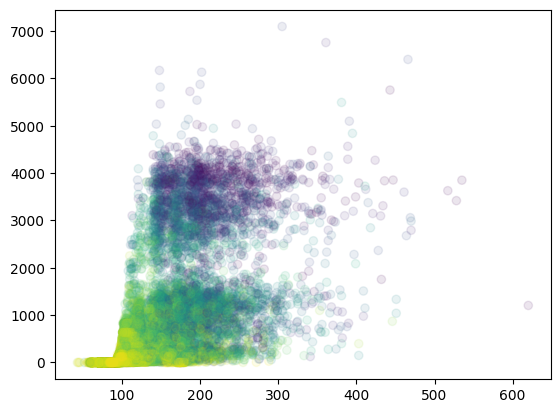

In [63]:
plt.scatter(df["duration"], df["total_gametocyte_density"], c=df["pfemp_variant_frac"], alpha=0.1)

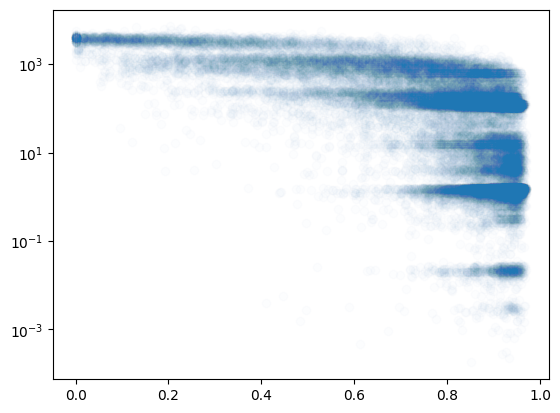

In [64]:
plt.scatter(df["pfemp_variant_frac"], df["total_gametocyte_density"], alpha=0.01)
plt.yscale("log")


In [65]:
np.linspace(-4, 4, 81)

array([-4. , -3.9, -3.8, -3.7, -3.6, -3.5, -3.4, -3.3, -3.2, -3.1, -3. ,
       -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2.3, -2.2, -2.1, -2. , -1.9,
       -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1. , -0.9, -0.8,
       -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,
        0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,  1.2,  1.3,  1.4,
        1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,  2.2,  2.3,  2.4,  2.5,
        2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,  3.3,  3.4,  3.5,  3.6,
        3.7,  3.8,  3.9,  4. ])

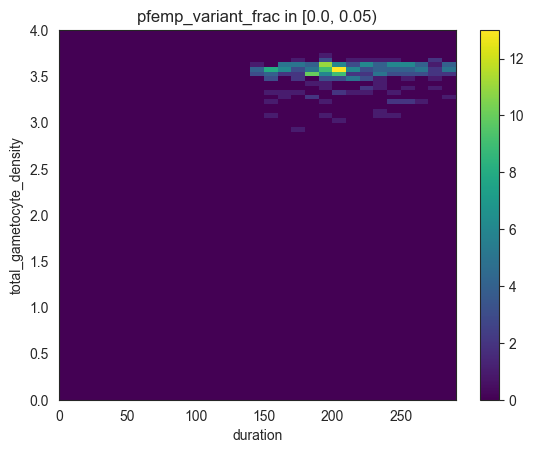

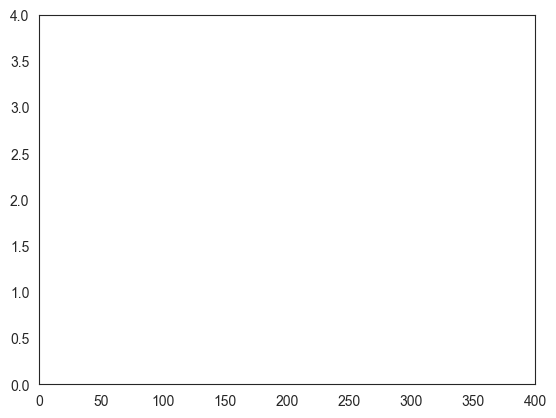

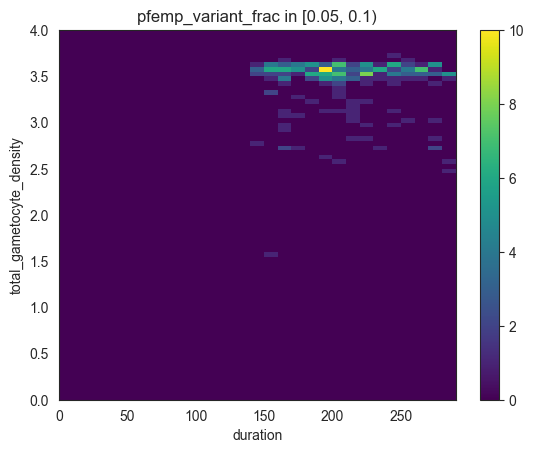

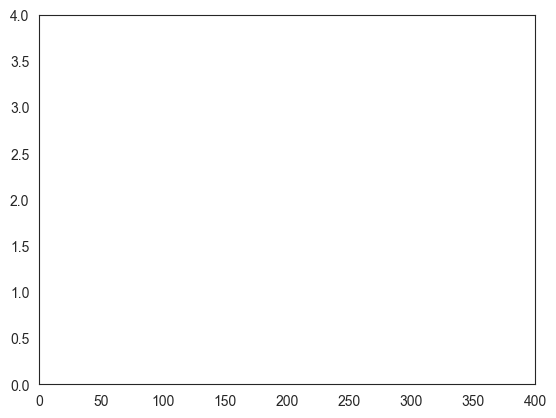

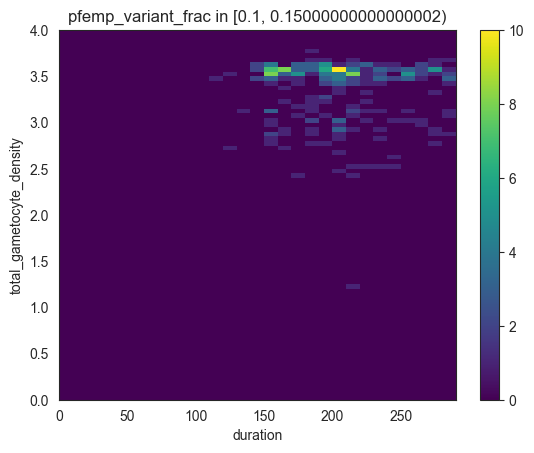

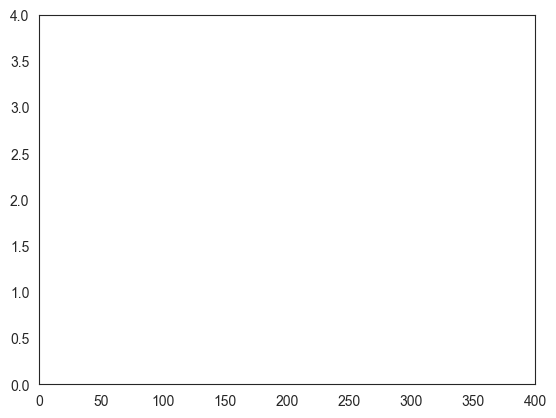

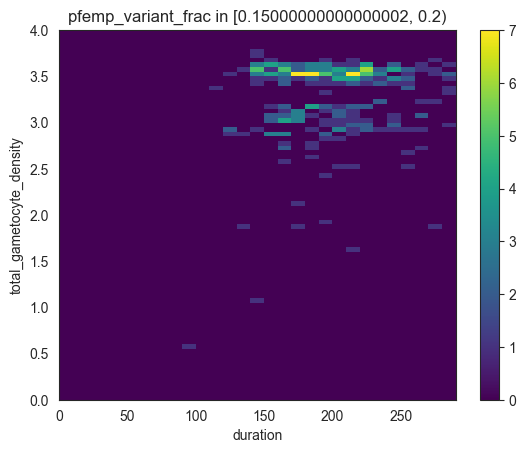

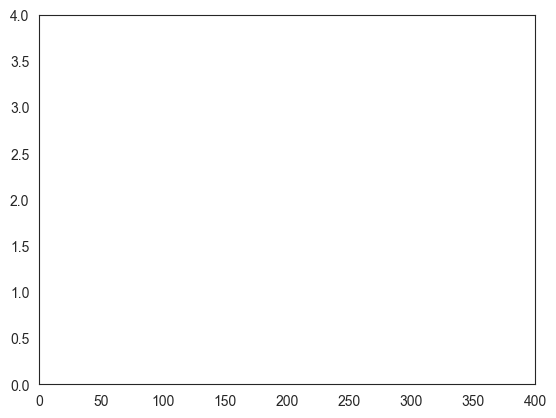

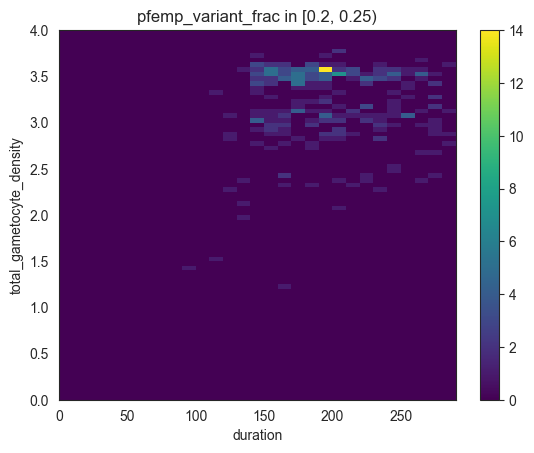

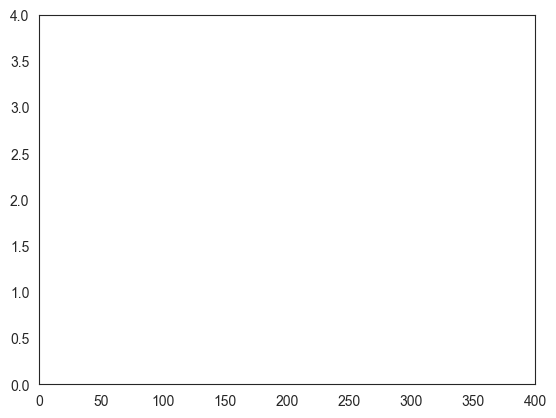

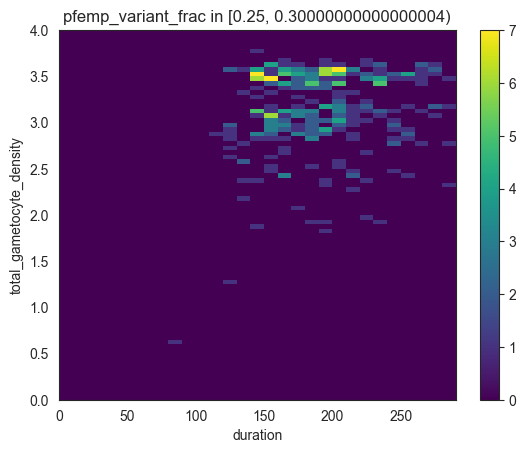

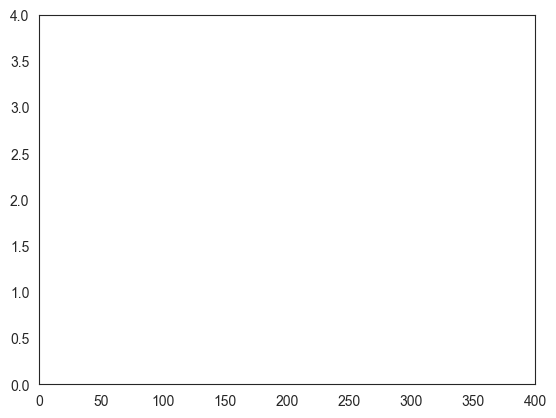

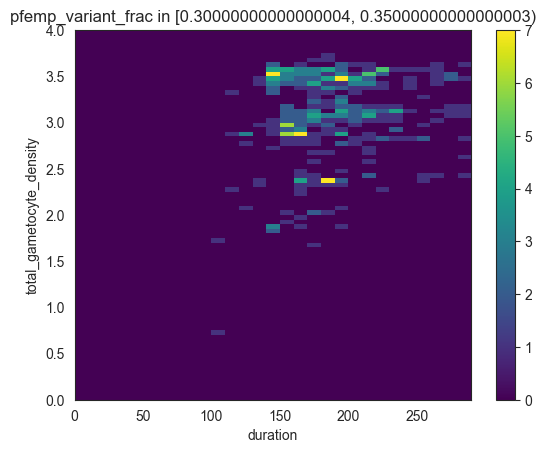

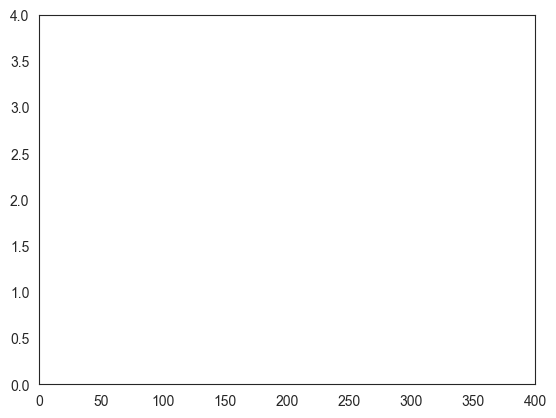

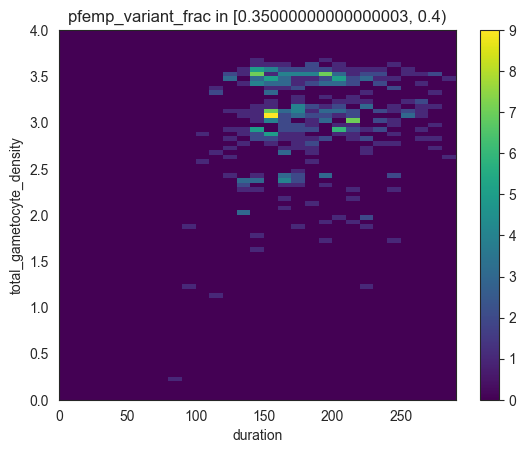

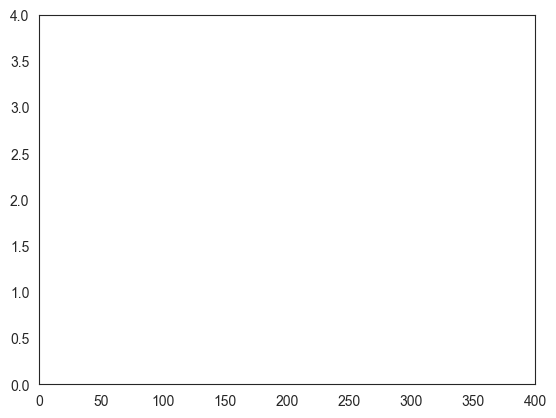

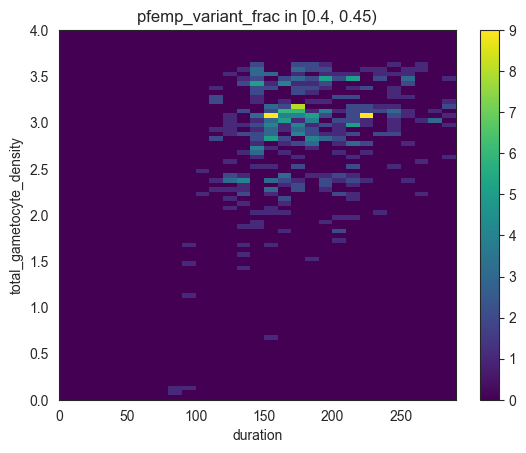

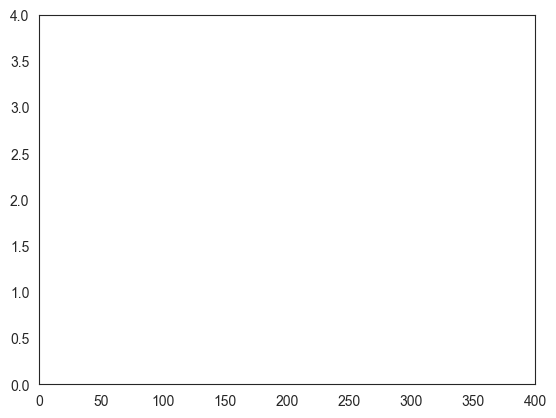

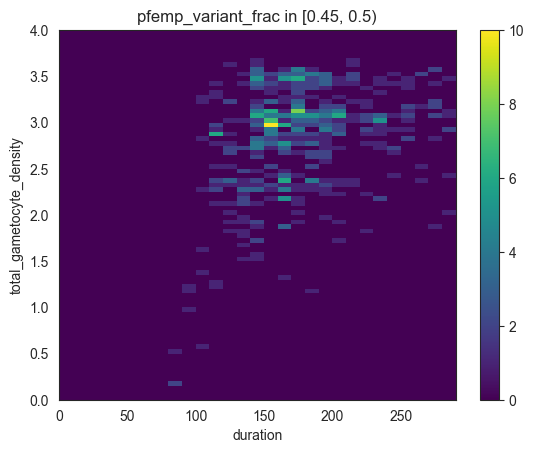

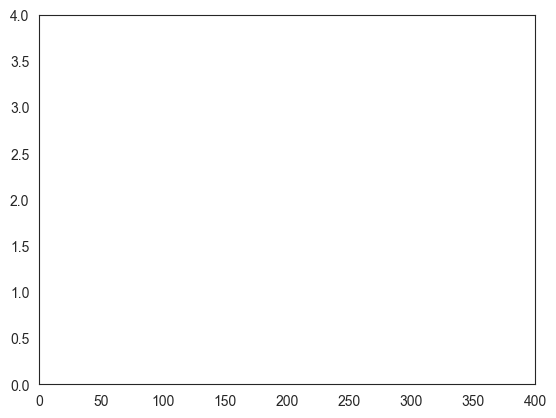

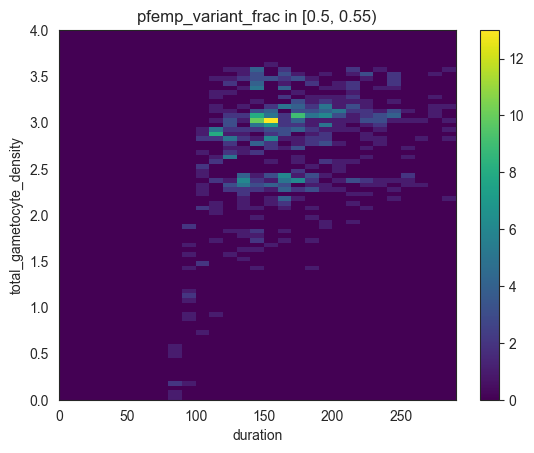

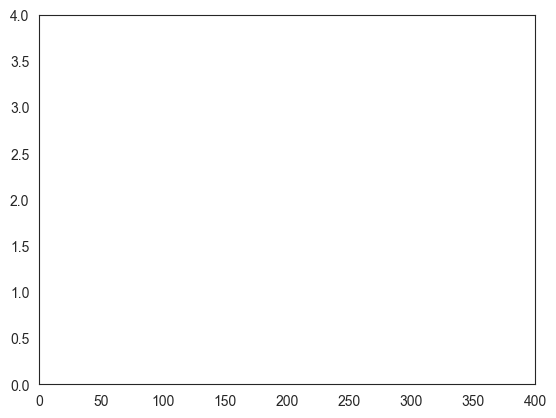

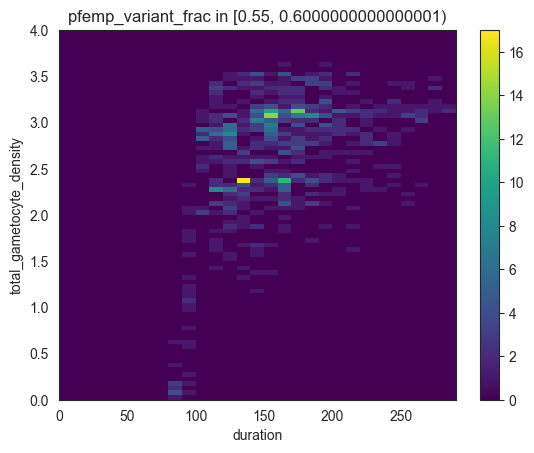

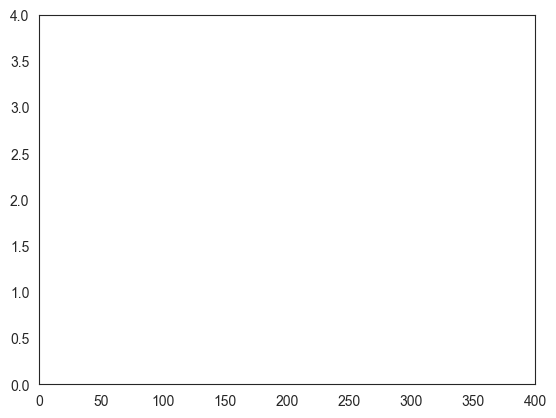

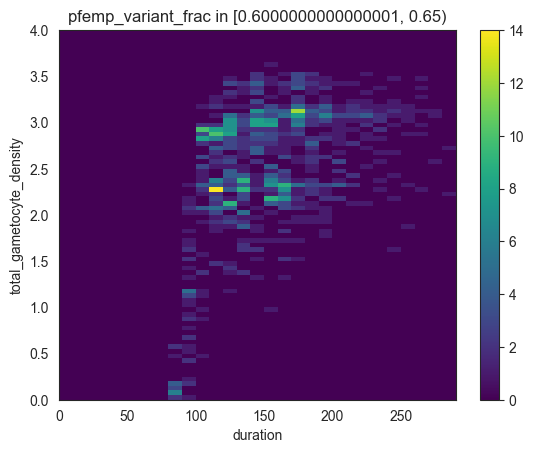

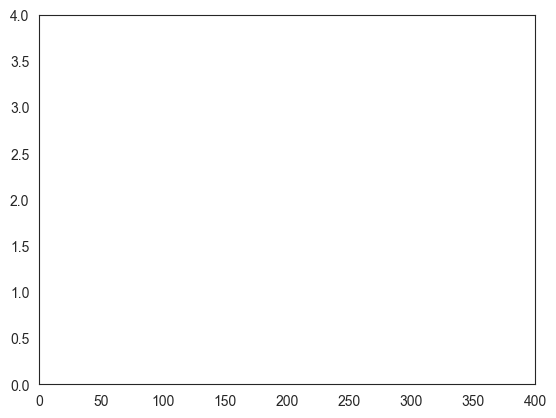

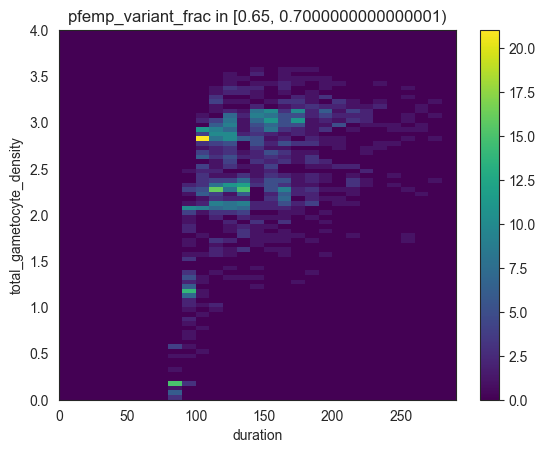

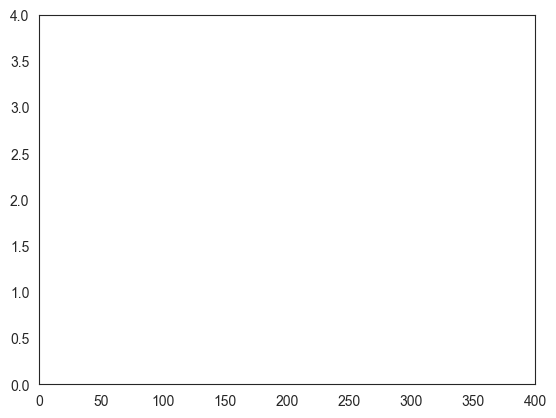

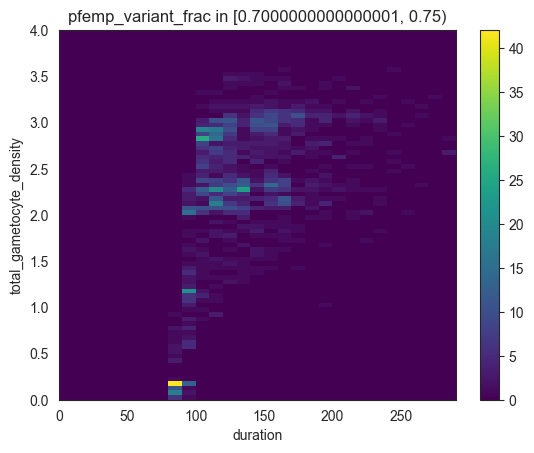

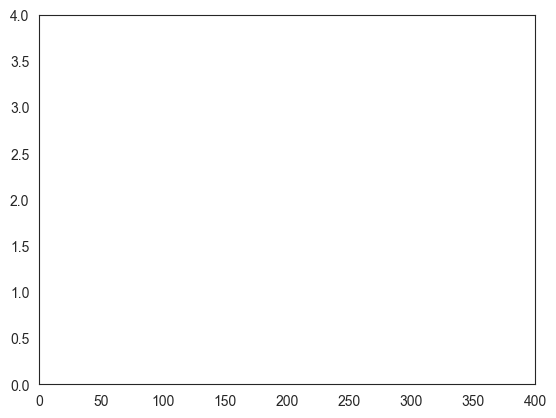

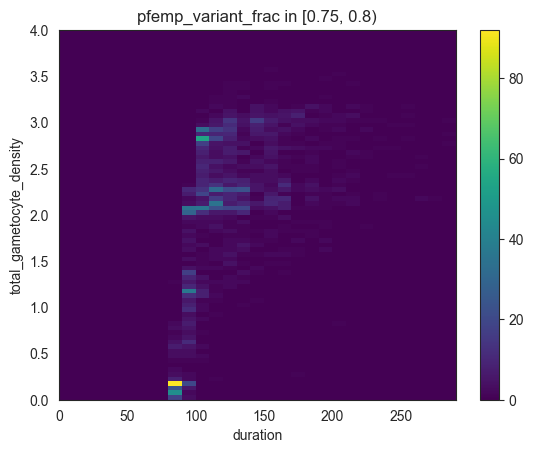

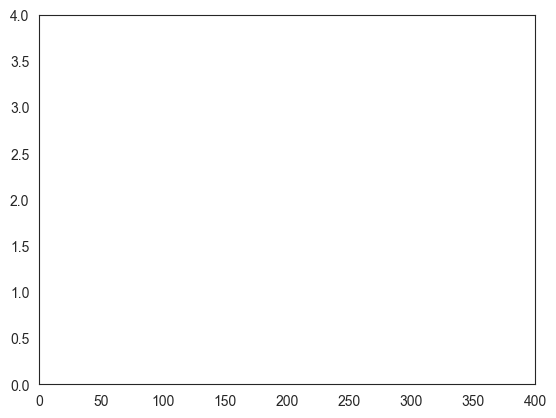

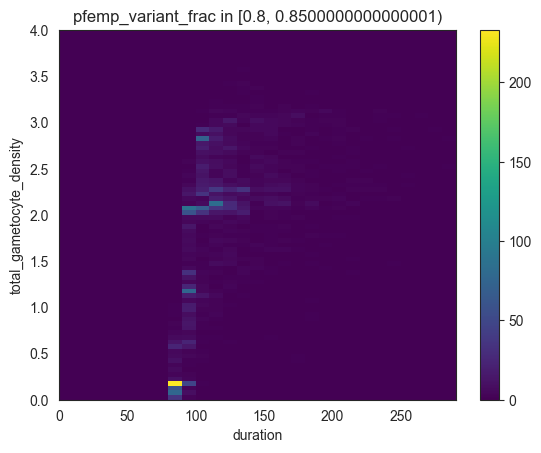

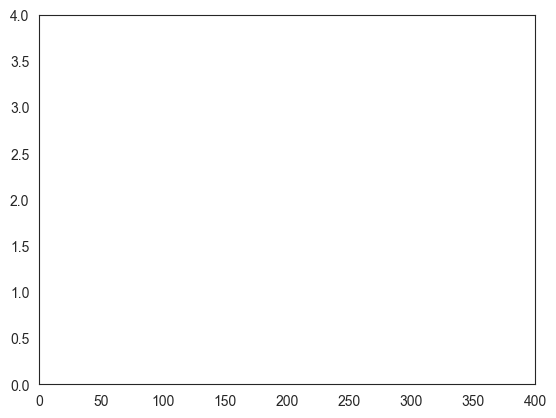

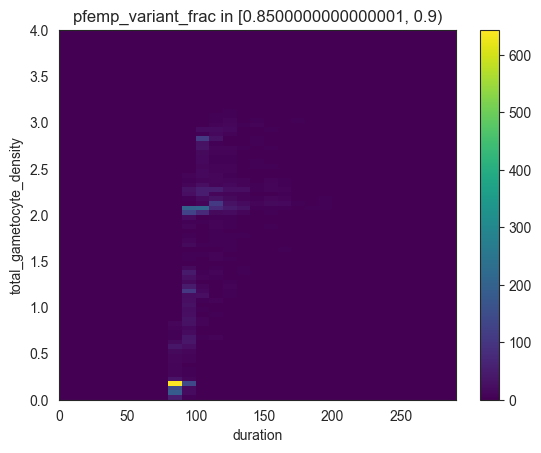

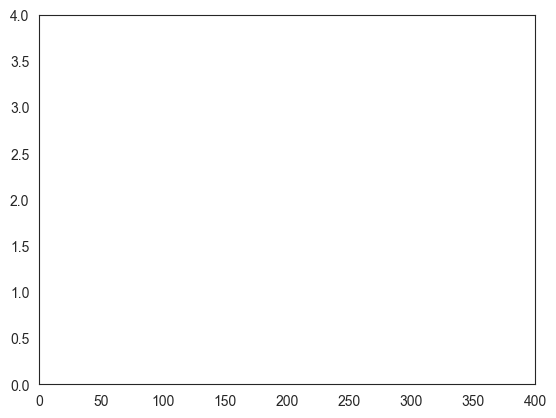

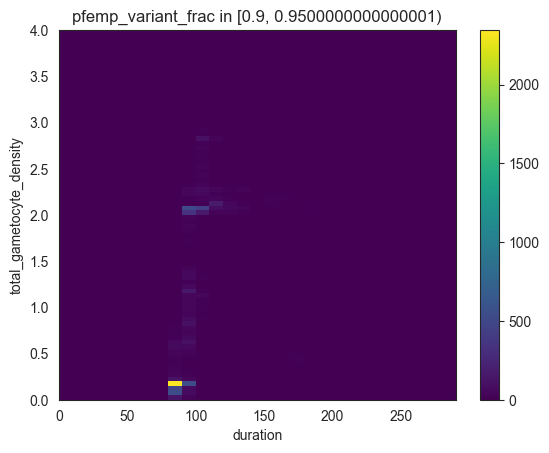

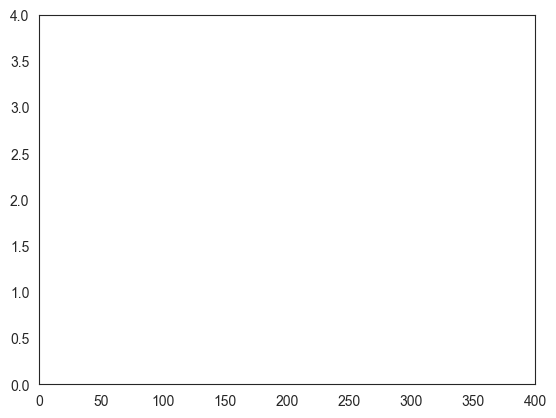

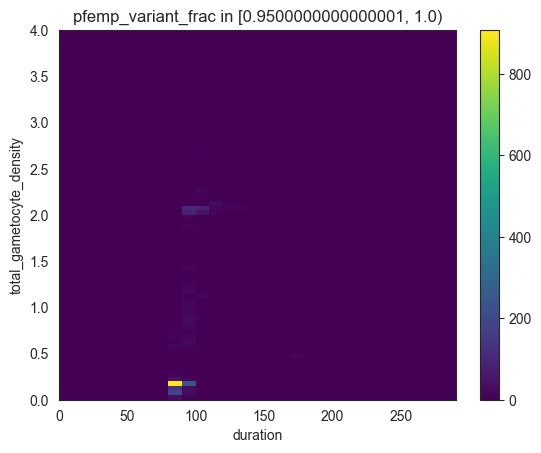

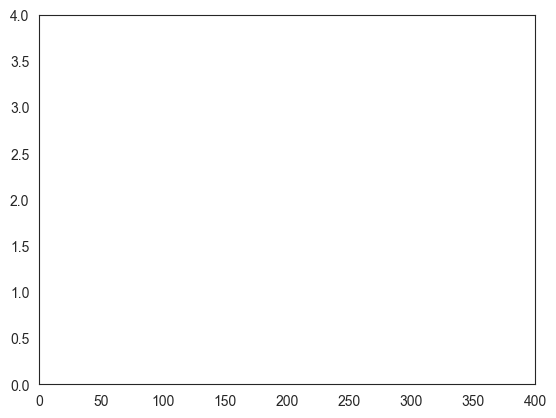

In [6]:
# Loop over pfemp_variant_frac bins and make 2D histogram of duration vs log(total_gametocyte_density)
bins = np.linspace(0, 1, 21)

# Use same bins for all plots
# duration_bins = np.arange(0, 600, 10)
duration_bins = np.arange(0, 300, 10)
# log10_gametocyte_density_bins = np.linspace(-4, 4, 81)
log10_gametocyte_density_bins = np.linspace(0, 4, 81)
for i in range(len(bins) - 1):
    plt.figure()
    mask = (df["pfemp_variant_frac"] >= bins[i]) & (df["pfemp_variant_frac"] < bins[i+1])
    plt.hist2d(df["duration"][mask], np.log10(df["total_gametocyte_density"][mask]), bins=(duration_bins, log10_gametocyte_density_bins), cmap="viridis")
    plt.colorbar()
    plt.xlabel("duration")
    plt.ylabel("total_gametocyte_density")
    plt.title(f"pfemp_variant_frac in [{bins[i]}, {bins[i+1]})")
    plt.show()
    plt.xlim([0, 400])
    plt.ylim([0,4])
    
    plt.savefig(f"pfemp_variant_frac_{bins[i]}_{bins[i+1]}.png")
    plt.savefig(f"pfemp_variant_frac_{bins[i]}_{bins[i+1]}.pdf")
    

In [67]:
df

,day,pfemp_variant_frac,infection_id,start_day,duration,total_gametocyte_density,human_id
0,85,0.025234,0,85,165,3284.959044,0
1,52,0.000000,1,52,264,1727.666964,0
2,48,0.000000,2,48,399,3496.682096,0
3,251,0.058879,3,251,206,4173.975590,0
4,323,0.077570,4,323,226,4113.914762,0
...,...,...,...,...,...,...,...
31809,14346,0.946729,303,14346,84,1.423862,99
31810,14348,0.946729,304,14348,87,1.558738,99
31811,14409,0.946729,305,14409,89,1.548259,99
31812,14458,0.946729,306,14458,88,1.468930,99


In [72]:
df["immunity_bin"] = pd.cut(df["pfemp_variant_frac"], bins=np.arange(0, 1.0+0.05, 0.05), include_lowest=True)

In [73]:
df

,day,pfemp_variant_frac,infection_id,start_day,duration,total_gametocyte_density,human_id,immunity_bin
0,85,0.025234,0,85,165,3284.959044,0,"(-0.001, 0.05]"
1,52,0.000000,1,52,264,1727.666964,0,"(-0.001, 0.05]"
2,48,0.000000,2,48,399,3496.682096,0,"(-0.001, 0.05]"
3,251,0.058879,3,251,206,4173.975590,0,"(0.05, 0.1]"
4,323,0.077570,4,323,226,4113.914762,0,"(0.05, 0.1]"
...,...,...,...,...,...,...,...,...
31809,14346,0.946729,303,14346,84,1.423862,99,"(0.9, 0.95]"
31810,14348,0.946729,304,14348,87,1.558738,99,"(0.9, 0.95]"
31811,14409,0.946729,305,14409,89,1.548259,99,"(0.9, 0.95]"
31812,14458,0.946729,306,14458,88,1.468930,99,"(0.9, 0.95]"


In [77]:
# Summarize data into bins:
def summarize_infections_v2(df):
    # Make 2D binning of Duration and Infectiousness 
    # and count the number of infections in each bin
    duration_bins = np.arange(0, 600+10, 5)
    log10_gametocyte_density_bins = np.linspace(-4, 4, 81)
    
    # Use pandas cut function to bin the data
    df['duration_bin'] = pd.cut(df['duration'], bins=duration_bins)
    df['log10_total_gametocyte_density_bin'] = pd.cut(np.log10(df['total_gametocyte_density']), bins=log10_gametocyte_density_bins)
    
    # Group by the bins and count the number of infections in each bin
    infection_counts = df.groupby(['duration_bin', 'log10_total_gametocyte_density_bin']).size().unstack(fill_value=0).fillna(0)
    
    # Melt
    melted_counts = infection_counts.reset_index().melt(id_vars=['duration_bin'], var_name='log10_total_gametocyte_density_bin', value_name='prob')
    
    # Remove bins with no infections
    melted_counts = melted_counts[melted_counts["prob"] > 0].reset_index(drop=True)
    
    # Normalize the infection counts by the sum of the counts
    melted_counts["prob"] = melted_counts["prob"] / melted_counts["prob"].sum()
    
    # Add bin edge info
    melted_counts["duration_bin_min"] = melted_counts["duration_bin"].apply(lambda x: x.left)
    melted_counts["duration_bin_max"] = melted_counts["duration_bin"].apply(lambda x: x.right)
    melted_counts["log10_total_gametocyte_density_bin_min"] = melted_counts["log10_total_gametocyte_density_bin"].apply(lambda x: x.left)
    melted_counts["log10_total_gametocyte_density_bin_max"] = melted_counts["log10_total_gametocyte_density_bin"].apply(lambda x: x.right)
    
    return melted_counts

In [78]:
all_dist = []
for ib, group in df.groupby('immunity_bin'):
    print(ib)
    foo = summarize_infections_v2(group)
    foo["immunity_bin"] = ib
    all_dist.append(foo)
all_dist_df = pd.concat(all_dist)

(-0.001, 0.05]
(0.05, 0.1]
(0.1, 0.15]
(0.15, 0.2]
(0.2, 0.25]
(0.25, 0.3]
(0.3, 0.35]
(0.35, 0.4]
(0.4, 0.45]
(0.45, 0.5]
(0.5, 0.55]
(0.55, 0.6]
(0.6, 0.65]
(0.65, 0.7]
(0.7, 0.75]
(0.75, 0.8]
(0.8, 0.85]
(0.85, 0.9]
(0.9, 0.95]
(0.95, 1.0]


In [79]:
all_dist_df

,duration_bin,log10_total_gametocyte_density_bin,prob,duration_bin_min,duration_bin_max,log10_total_gametocyte_density_bin_min,log10_total_gametocyte_density_bin_max,immunity_bin
0,"(175, 180]","(2.9, 3.0]",0.003236,175,180,2.9,3.0,"(-0.001, 0.05]"
1,"(150, 155]","(3.0, 3.1]",0.003236,150,155,3.0,3.1,"(-0.001, 0.05]"
2,"(195, 200]","(3.0, 3.1]",0.003236,195,200,3.0,3.1,"(-0.001, 0.05]"
3,"(205, 210]","(3.0, 3.1]",0.003236,205,210,3.0,3.1,"(-0.001, 0.05]"
4,"(230, 235]","(3.0, 3.1]",0.003236,230,235,3.0,3.1,"(-0.001, 0.05]"
...,...,...,...,...,...,...,...,...
206,"(115, 120]","(2.7, 2.8]",0.000353,115,120,2.7,2.8,"(0.95, 1.0]"
207,"(100, 105]","(2.8, 2.9]",0.001060,100,105,2.8,2.9,"(0.95, 1.0]"
208,"(105, 110]","(2.8, 2.9]",0.001060,105,110,2.8,2.9,"(0.95, 1.0]"
209,"(110, 115]","(2.8, 2.9]",0.000707,110,115,2.8,2.9,"(0.95, 1.0]"


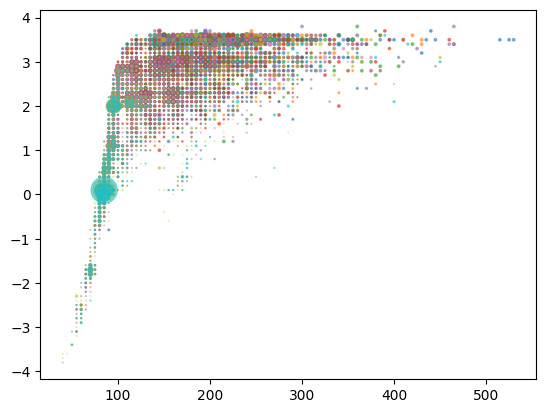

In [81]:
for i,g in all_dist_df.groupby("immunity_bin"):
    plt.scatter(g["duration_bin_min"], g["log10_total_gametocyte_density_bin_min"], s=g["prob"]*1000, alpha=0.5, label=i)

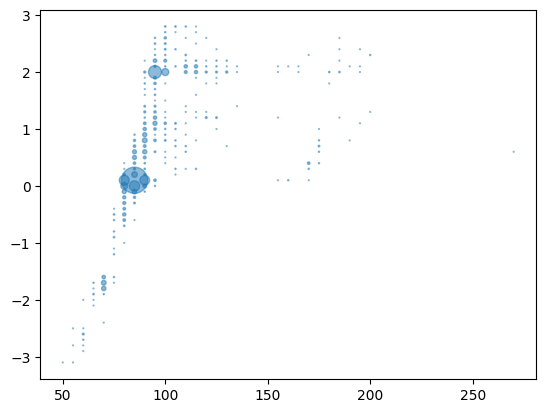

In [82]:
plt.scatter(g["duration_bin_min"], g["log10_total_gametocyte_density_bin_min"], s=g["prob"]*1000, alpha=0.5, label=i)

In [86]:
# Sort all_dist_df by immunity_bin, duration_bin_min, and log10_total_gametocyte_density_bin_min, in that order
all_dist_df = all_dist_df.sort_values(["immunity_bin", "duration_bin_min", "log10_total_gametocyte_density_bin_min"]).reset_index(drop=True)

In [87]:
all_dist_df

,duration_bin,log10_total_gametocyte_density_bin,prob,duration_bin_min,duration_bin_max,log10_total_gametocyte_density_bin_min,log10_total_gametocyte_density_bin_max,immunity_bin
0,"(135, 140]","(3.6, 3.7]",0.003236,135,140,3.6,3.7,"(-0.001, 0.05]"
1,"(140, 145]","(3.5, 3.6]",0.009709,140,145,3.5,3.6,"(-0.001, 0.05]"
2,"(145, 150]","(3.4, 3.5]",0.003236,145,150,3.4,3.5,"(-0.001, 0.05]"
3,"(145, 150]","(3.5, 3.6]",0.012945,145,150,3.5,3.6,"(-0.001, 0.05]"
4,"(150, 155]","(3.0, 3.1]",0.003236,150,155,3.0,3.1,"(-0.001, 0.05]"
...,...,...,...,...,...,...,...,...
6034,"(195, 200]","(2.1, 2.2]",0.000353,195,200,2.1,2.2,"(0.95, 1.0]"
6035,"(195, 200]","(2.4, 2.5]",0.000353,195,200,2.4,2.5,"(0.95, 1.0]"
6036,"(200, 205]","(1.3, 1.4]",0.000353,200,205,1.3,1.4,"(0.95, 1.0]"
6037,"(200, 205]","(2.3, 2.4]",0.000707,200,205,2.3,2.4,"(0.95, 1.0]"


In [88]:
all_dist_df.to_csv("emod_infection_summary_gametocytes.csv", index=False)

In [58]:
10**np.min(np.log10(df["total_gametocyte_density"]))

0.00017859999992699994

In [29]:
np.max(np.log10(df["total_gametocyte_density"]))

3.851009696392482

In [59]:
10**np.max(np.log10(df["total_gametocyte_density"]))

7095.936107190068

In [30]:
df

,day,pfemp_variant_frac,infection_id,start_day,duration,total_gametocyte_density,human_id
0,85,0.025234,0,85,165,3284.959044,0
1,52,0.000000,1,52,264,1727.666964,0
2,48,0.000000,2,48,399,3496.682096,0
3,251,0.058879,3,251,206,4173.975590,0
4,323,0.077570,4,323,226,4113.914762,0
...,...,...,...,...,...,...,...
31809,14346,0.946729,303,14346,84,1.423862,99
31810,14348,0.946729,304,14348,87,1.558738,99
31811,14409,0.946729,305,14409,89,1.548259,99
31812,14458,0.946729,306,14458,88,1.468930,99


In [32]:
# from network_sim.host import draw_gametocyte_shape_parameters

def draw_gametocyte_shape_parameters(infection_durations, y_floor=1e-4):

    N_infections = len(infection_durations)

    t_first_max = np.random.randint(34, 37, size=N_infections)
    h_first_max = np.random.uniform(10, 20, size=N_infections)

    # m_decay = np.random.uniform(-0.15, -0.07, size=N_infections)

    # Gametocytes rapidly decay after first peak.
    # Slope is uniformly drawn from [-0.15,-0.07], and then stays at floor of y_floor
    # However, for very short infections, take more steep slow to ensure that we end at y_floor
    m_decay = np.empty(N_infections)
    for i in range(N_infections):
        m_decay_max = (np.log(y_floor) - np.log(h_first_max[i])) / (infection_durations[i] - t_first_max[i])

        if m_decay_max < -0.15:
            m_decay[i] = m_decay_max
        elif m_decay_max > -0.07:
            m_decay[i] = np.random.uniform(-0.15, -0.07)
        else:
            m_decay[i] = np.random.uniform(-0.15, m_decay_max)

    return t_first_max, h_first_max, m_decay

In [35]:
def current_gametocyte_density(infection_age, infection_duration, aggregate_gametocyte_density, t_first_max, h_first_max, m_decay, y_floor=1e-4):
    # Return gametocyte density at a given time point in the infection
    if infection_age <= 21:
        return 0.

    # Gametocytes show up after 21 days and rise rapidly to first peak
    t_start = 21
    h_start = 1e-4

    m_rise = (np.log(h_first_max) - np.log(h_start)) / (t_first_max - t_start)
    b_rise = np.log(h_start) - m_rise * t_start
    y_rise = np.exp(m_rise * np.arange(t_start, t_first_max+1) + b_rise)

    # Gametocytes rapidly decay after first peak.
    b_decay = np.log(h_first_max) - m_decay * t_first_max
    y_decay = np.exp(m_decay * np.arange(t_first_max, infection_duration+1) + b_decay)

    y_rise_and_decay = np.concatenate([y_rise, y_decay])
    # Rescale to have total sum to 1
    y_rise_and_decay = y_rise_and_decay / np.sum(y_rise_and_decay)

    # Now impose floor (note that doing this after the rescaling will not guarantee that the mean is 1, but it's close enough)
    y_rise_and_decay = np.maximum(y_rise_and_decay, y_floor)

    return y_rise_and_decay[int(infection_age) - 21] * aggregate_gametocyte_density

In [52]:
# from network_sim.host import infectiousness_from_gametocyte_density

def infectiousness_from_gametocyte_density(gametocyte_density):
    # EMOD function which relates gametocyte density to infectiousness
    base_gametocyte_mosquito_survival = 0.002011099
    return 1 - np.exp(-base_gametocyte_mosquito_survival * gametocyte_density)

In [53]:
p = draw_gametocyte_shape_parameters([89])

g = np.zeros(89)
ii = np.zeros(89)

for t in range(89):
    g[t] = current_gametocyte_density(t, 89, 1.2, *p)
    
    
    ii[t] = infectiousness_from_gametocyte_density(g[t])

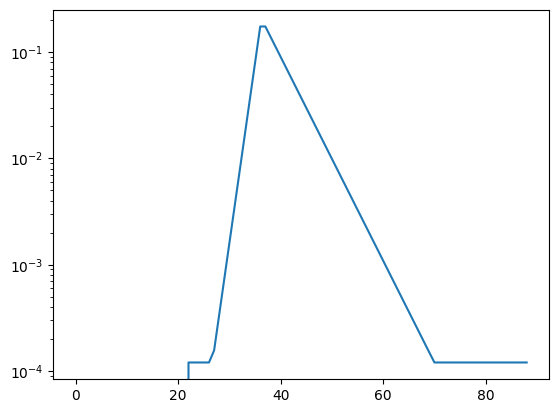

In [48]:
plt.plot(g)
plt.yscale("log")

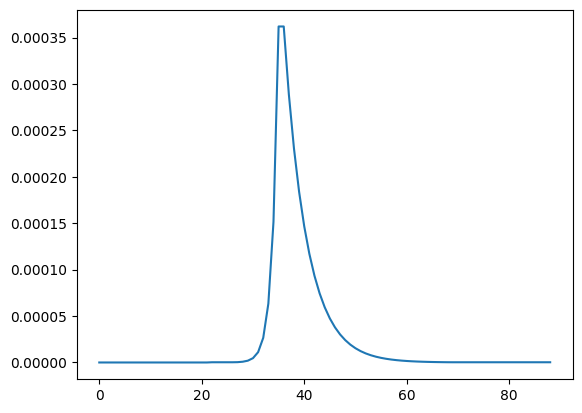

In [56]:
plt.plot(ii)
# plt.yscale("log")

In [57]:
infectiousness_from_gametocyte_density(0.1)

0.00020108967875964723